In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# get data 80

In [9]:
import os
from att_tools import remove_conf
from yolo_tools import copy_ref_csv

In [5]:
datav16_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data7961_mseg_c5_l2_1112_v16'
data80_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v16'
input_image_dir = os.path.join(datav16_dir, 'images')
input_label_dir = os.path.join(datav16_dir, 'labels')
input_val_test_path = os.path.join(datav16_dir, 'val_test.txt')
data80_image_dir = os.path.join(data80_dir, 'images')
data80_label_dir = os.path.join(data80_dir, 'labels')

In [ ]:
copy_ref_csv(input_image_dir, data80_image_dir, input_val_test_path)
copy_ref_csv(input_label_dir, data80_label_dir, input_val_test_path)

In [ ]:
# val 2 pred

In [6]:
val_dir = r'/localnvme/project/ultralytics/runs/msegment/val761/labels'
pred_dir = os.path.join(data80_dir, 'val761')


In [10]:
remove_conf(val_dir, pred_dir)

remove_conf: 100%|██████████| 80/80 [00:00<00:00, 270.32it/s]


In [ ]:
# vis and check

In [13]:
from att_tools import vis_matched_result

In [12]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v16'
image_dir = os.path.join(base_dir, 'images')
label_dir = os.path.join(base_dir, 'labels')
val_test_dir = os.path.join(base_dir, 'val_test')
image_test_dir = os.path.join(val_test_dir, 'images')
label_test_dir = os.path.join(val_test_dir, 'labels')
result_analysis_dir = os.path.join(base_dir, 'result_analysis')
vis_dir = os.path.join(result_analysis_dir, 'vis')
class_path = os.path.join(base_dir, 'class.txt')
att_path = os.path.join(base_dir, 'attribute.yaml')
val_test_path = os.path.join(base_dir, 'val_test.txt')
pred_dir = os.path.join(base_dir, 'val761')




In [14]:
vis_matched_result(
    image_dir,
    label_dir,
    pred_dir,
    vis_dir,
    class_path,
    att_path,
    with_conf=False,
    annotation=True,
    iou_thr=0.3,
    conf_threshold=0.4,
    defect_conf_threshold=0.001,
    filter_small=0.05,
    save_method='attribute',
    crop_method='with_background_box_shape',
)

read and process label: 100%|██████████| 80/80 [00:26<00:00,  3.03it/s]


In [27]:
# get data v17

In [28]:
import os
import shutil
from data_vis.yolo_sta import yolo_sta
from att_tools import risk_remove_high
from yolo_tools import copy_all, copy_split, data_tf_pipline_new

In [29]:
base_dir = r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030'
image_dir = os.path.join(base_dir, 'images')
label_dir = os.path.join(base_dir, 'labels_v10')
label_ana_dir = os.path.join(base_dir, 'labels_analysis')
attribute_file = os.path.join(base_dir, 'attribute.yaml')
class_file = os.path.join(base_dir, 'class.txt')
class_c6_path = r'/localnvme/data/billboard/class_c6.txt'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l3_path = r'/localnvme/data/billboard/attribute.yaml'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'
input_dir = base_dir
input_train_test_path = os.path.join(input_dir, 'train_test.txt')
input_val_test_path = os.path.join(input_dir, 'val_test.txt')
input_train_80p_path = os.path.join(input_dir, 'train_80p_ref.txt')
input_val_80p_path = os.path.join(input_dir, 'val_80p_ref.txt')
input_all_path = os.path.join(input_dir, 'all.txt')
input_all_test_path = os.path.join(input_dir, 'all_test.txt')
label_v16_dir = os.path.join(base_dir, 'labels_v16')
label_v17_dir = os.path.join(base_dir, 'labels_v17')
label_v16_sta_dir = os.path.join(label_ana_dir, 'labels_v16_sta')
label_v17_sta_dir = os.path.join(label_ana_dir, 'labels_v17_sta')
datav17_dir =  r'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1113_v17'


label read: 100%|██████████| 7946/7946 [01:09<00:00, 115.09it/s]


get 7946 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61808 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v16_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61808; 有缺陷的box数: 4024; 没有缺陷的box数: 57784
总image数: 7840; 有缺陷的image数: 2715; 没有缺陷的image数: 5125
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   147                 0                  43   
abandonment              883                 6                 141   
corrosion                127              1096                1319   
attribute sum           1137              1100                1596   
with attribute          1137              1100                1596   

category        hanging frame  hanging display  o

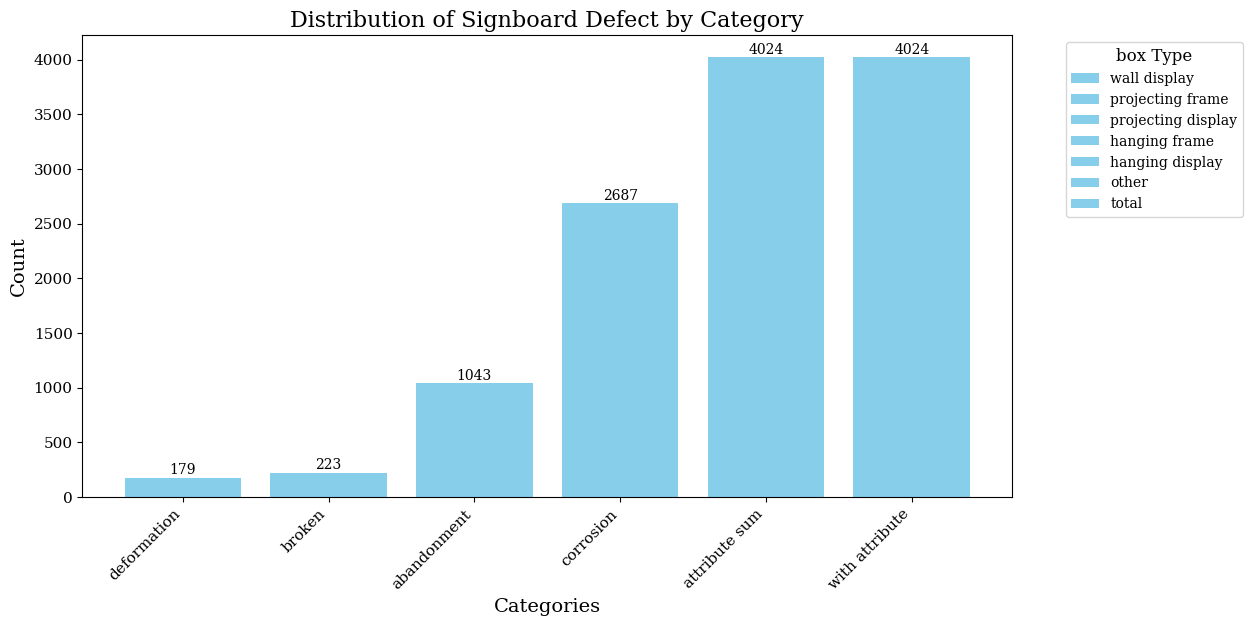

In [30]:
yolo_sta(
    gt_dir=label_v16_dir,
    result_dir=label_v16_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

label read: 100%|██████████| 7946/7946 [01:05<00:00, 120.77it/s]


get 7946 labels, merging...


/localnvme/project/dataset_tools/data_vis/yolo_sta.py:303: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfs = pd.concat(dfs)


merging finish, get 61808 labels!
csv save to /localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1030/labels_analysis/labels_v17_sta/sta_attribute.csv
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
总box数: 61808; 有缺陷的box数: 4033; 没有缺陷的box数: 57775
总image数: 7840; 有缺陷的image数: 2717; 没有缺陷的image数: 5123
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
category        wall display  projecting frame  projecting display  \
deformation                9                 7                 159   
broken                   147                 0                  43   
abandonment              883                 6                 141   
corrosion                127              1104                1320   
attribute sum           1137              1108                1597   
with attribute          1137              1108                1597   

category        hanging frame  hanging display  o

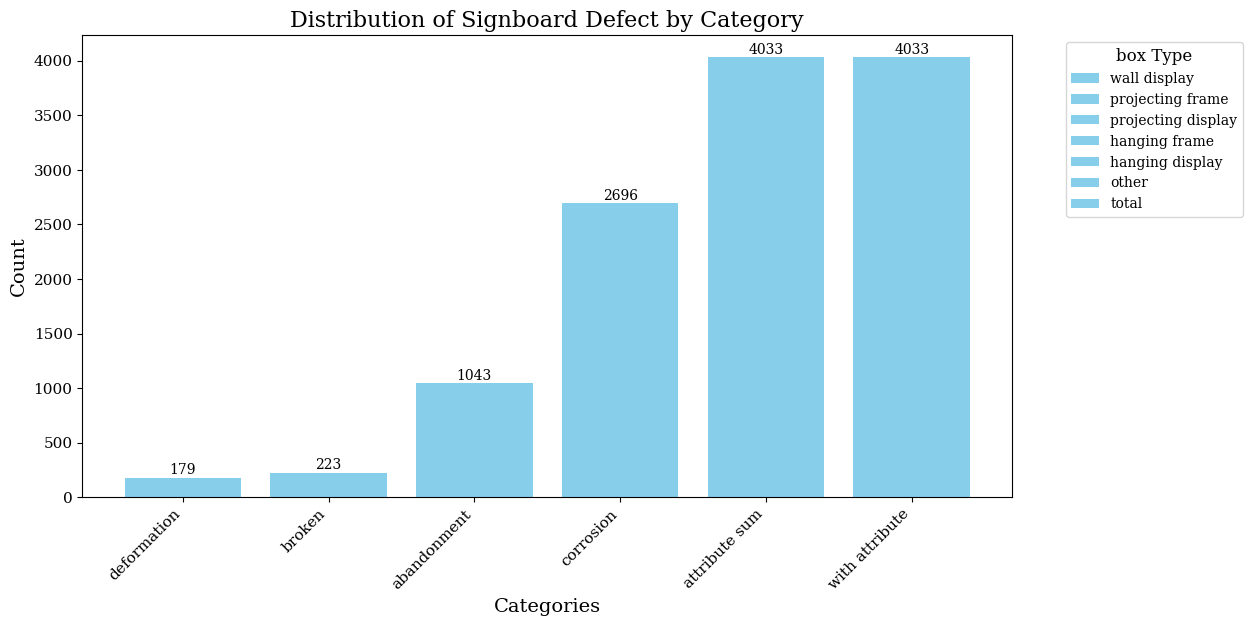

In [31]:
yolo_sta(
    gt_dir=label_v17_dir,
    result_dir=label_v17_sta_dir,
    class_path=class_file,
    attribute_path=attribute_file,
    seg=True,
)

In [32]:
copy_all(
    label_v17_dir,
    os.path.join(datav17_dir, 'labels'),
    image_dir,
    os.path.join(datav17_dir, 'images'),
)

copy_all: 100%|██████████| 7946/7946 [00:17<00:00, 447.94it/s]


In [33]:
output_dir = datav17_dir
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path)
copy_split(input_val_test_path, output_val_test_path)
copy_split(input_train_80p_path, output_train_80p_path)
copy_split(input_val_80p_path, output_val_80p_path)
copy_split(input_all_path, output_all_path)
copy_split(input_all_test_path, output_all_test_path)

shutil.copy(class_c6_path, os.path.join(output_dir, 'class.txt'))
shutil.copy(att_l3_path, os.path.join(output_dir, 'attribute.yaml'))

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


'/localnvme/data/billboard/all_data/mseg_c6/data7961_mseg_c6_1113_v17/attribute.yaml'

In [34]:
data_tf_pipline_new(datav17_dir, copy_list=['mseg_c5_l2', 'seg_c5'])

mseg2seg:: 100%|██████████| 7946/7946 [00:17<00:00, 442.85it/s]


In [35]:
output_dir = datav17_dir.replace('mseg_c6', 'mseg_c5_l2')
output_train_test_path = os.path.join(output_dir, 'train_test.txt')
output_val_test_path = os.path.join(output_dir, 'val_test.txt')
output_train_80p_path = os.path.join(output_dir, 'train_80p_ref.txt')
output_val_80p_path = os.path.join(output_dir, 'val_80p_ref.txt')
output_all_path = os.path.join(output_dir, 'all.txt')
output_all_test_path = os.path.join(output_dir, 'all_test.txt')

copy_split(input_train_test_path, output_train_test_path, abs_path=True)
copy_split(input_val_test_path, output_val_test_path, abs_path=True)
copy_split(input_train_80p_path, output_train_80p_path, abs_path=True)
copy_split(input_val_80p_path, output_val_80p_path, abs_path=True)
copy_split(input_all_path, output_all_path, abs_path=True)
copy_split(input_all_test_path, output_all_test_path, abs_path=True)

copy train_test.txt, 7872 records
copy val_test.txt, 80 records
copy train_80p_ref.txt, 7606 records
copy val_80p_ref.txt, 266 records
copy all.txt, 7872 records
copy all_test.txt, 7952 records


In [36]:
# get test v17

In [37]:
from yolo_mask_crop import myolo_crop

In [38]:
datav15_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data7961_mseg_c5_l2_1113_v17'
data80_dir = r'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v17'
class_c5_path = r'/localnvme/data/billboard/class_c5.txt'
att_l2_path = r'/localnvme/data/billboard/attribute_l2.yaml'

input_image_dir = os.path.join(datav15_dir, 'images')
input_label_dir = os.path.join(datav15_dir, 'labels')
input_val_test_path = os.path.join(datav15_dir, 'val_test.txt')

data80_image_dir = os.path.join(data80_dir, 'images')
data80_label_dir = os.path.join(data80_dir, 'labels')
data80_result_analysis_dir = os.path.join(data80_dir, 'result_analysis')
data80_class_path = os.path.join(data80_dir, 'class.txt')
data80_att_path = os.path.join(data80_dir, 'attribute.yaml')

In [39]:
copy_ref_csv(input_image_dir, data80_image_dir, input_val_test_path)

100%|██████████| 80/80 [00:00<00:00, 940.99it/s]


In [40]:
copy_ref_csv(input_label_dir, data80_label_dir, input_val_test_path)

100%|██████████| 80/80 [00:00<00:00, 10439.76it/s]


In [41]:
shutil.copy(class_c5_path, data80_class_path)
shutil.copy(att_l2_path, data80_att_path)

'/localnvme/data/billboard/all_data/mseg_c5_l2/data80_v17/attribute.yaml'

In [42]:
image_dir = data80_image_dir
label_dir = data80_label_dir
image_crop_dir = label_dir+'_crop'

In [44]:
myolo_crop(
    image_dir,
    label_dir,
    image_crop_dir,
    data80_class_path,
    attribute_file=data80_att_path,
    seg=True,
    annotation=False,
    save_method='attribute',
    only_defect=True,
    with_boundary=True,
    crop_method='with_background_box_shape'
)

100%|██████████| 738/738 [00:00<00:00, 189078.03it/s]
